In [243]:
import torch

In [244]:
### Select device (GPU)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
print('Selected device:', device)

Selected device: cuda


In [245]:
with open('../data-sets/tiny_shakespeare.txt', 'r', encoding='utf-8') as f:
    text = f.read()

dataset = text

import random
print('Random line:', random.choice(dataset.split('\n')))
print('Size of dataset:', len(dataset.split('\n')), 'lines')

Random line: KING EDWARD IV:
Size of dataset: 40001 lines


In [246]:
unique_chars = sorted(set(dataset))

print(unique_chars)

char_to_num = {char: num for num, char in enumerate(unique_chars)}
num_to_char = {num: char for char, num in char_to_num.items()}

vocab_size = len(unique_chars) # Vocabulary size |V|
print('Number of unique chars:', vocab_size)

['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Number of unique chars: 65


In [247]:
import torch
import random
import torch.nn.functional as F

### Create data set ###
seq_len = 20

def build_dataset(data):
    X, Y = [], []
    
    context = [0] * seq_len
    
    for ch in data:
        X.append(context)
        ix = char_to_num[ch]
        context = context[1:] + [ix]
        Y.append(context)

    X = torch.tensor(X, device=device)
    Y = torch.tensor(Y, device=device)

    return X, Y

split = int(0.8 * len(dataset))

Xtr, Ytr = build_dataset(dataset[:split])
Xte, Yte = build_dataset(dataset[split:])

ix = random.randint(0, len(Xtr) - 1) 
print('Training data shape:', Xtr.shape, '=>', Ytr.shape)
print('Random example:', Xtr[ix].tolist(), '=>', Ytr[ix].tolist())
print('Amount of train examples:', len(Xtr))

Training data shape: torch.Size([892315, 20]) => torch.Size([892315, 20])
Random example: [1, 58, 46, 43, 52, 1, 57, 39, 63, 0, 25, 63, 1, 61, 47, 44, 43, 5, 57, 1] => [58, 46, 43, 52, 1, 57, 39, 63, 0, 25, 63, 1, 61, 47, 44, 43, 5, 57, 1, 39]
Amount of train examples: 892315


In [248]:
import torch.nn as nn

emb_dim = 20
hidden_size = 250

class RNN(nn.Module):
    def __init__(self, hidden_size):
        super(RNN, self).__init__()

        self.hidden_size = hidden_size

        self.embeddings = nn.Embedding(vocab_size, emb_dim)
        self.rnn        = nn.RNN(emb_dim, hidden_size, batch_first=True)
        self.fc         = nn.Linear(hidden_size, vocab_size)

    def forward(self, input):    
        is_batch = input.ndim == 2

        if is_batch:
            h0 = torch.zeros(1, input.size(0), self.hidden_size).to(input.device)
        elif input.ndim == 1:
            h0 = torch.zeros(1, self.hidden_size).to(input.device)

        embs = self.embeddings(input) # (B x Seq len x emb dim)

        output, _ = self.rnn(embs, h0)
        out = self.fc(output)

        if is_batch:
            out = out.permute(0, 2, 1)
        # else:
        #     out = out.permute(1, 0)
        
        return out

model = RNN(hidden_size).to(device)

print('Total parameters:', sum(p.numel() for p in model.parameters()))

Total parameters: 85615


In [249]:
lr = 0.0003

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [250]:
import torch.nn.functional as F

### Train model ###
epochs = 100000
batch_size = 128
eval_batch_size = 10000

epoch_count = []
train_loss_values = []
test_loss_values = []
ud = []

from tqdm import trange
for epoch in trange(epochs):
    model.train()
    
    # Sample mini-batch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), device=device)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Logits shape = B x Seq len x vocab size
    # Targets      = B x Seq len

    output = model(Xb)           # Do the forward pass

    # print('Logits shape:', output.shape)
    # print('Targets shape:', Yb.shape)

    loss = criterion(output, Yb) # Calculate the loss
    optimizer.zero_grad()        # Reset parameters
    loss.backward()              # Backpropagation
    optimizer.step()             # Update parameters

    # Report progression every so often
    if ((epoch + 1) % (epochs / 50) == 0):
        
        # Sample larger train-batch
        ix = torch.randint(0, Xtr.shape[0], (eval_batch_size,), device=device)
        Xb, Yb = Xtr[ix], Ytr[ix]

        model.eval()
        with torch.inference_mode():
            outputs = model(Xb)
            loss = F.cross_entropy(outputs, Yb)

            ud.append([((lr * p.grad).std() / p.data.std()).log10().item() for p in model.parameters()])

        # Sample larger test-batch
        ix = torch.randint(0, Xte.shape[0], (eval_batch_size,), device=device)
        Xb, Yb = Xte[ix], Yte[ix]

        model.eval()
        with torch.inference_mode():
            outputs = model(Xb)
            test_loss = F.cross_entropy(outputs, Yb)
        
        epoch_count.append(epoch)
        train_loss_values.append(loss.detach().item())
        test_loss_values.append(test_loss.detach().item())

# Print final results
print('Final training loss:', round(loss.detach().item(), 3))
print('Final test loss:', round(test_loss.detach().item(), 3))

  0%|          | 199/100000 [00:00<01:40, 995.95it/s]

100%|██████████| 100000/100000 [01:36<00:00, 1033.04it/s]

Final training loss: 1.429
Final test loss: 1.754


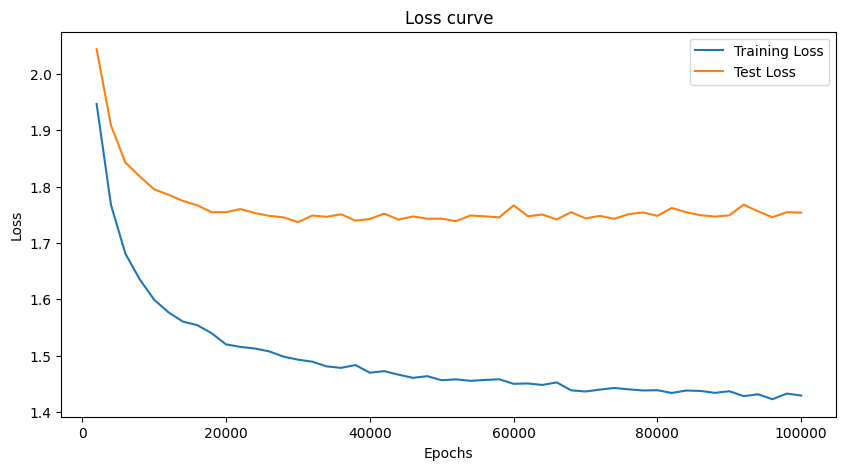

In [251]:
import matplotlib.pyplot as plt

### Visualize loss progression ###
plt.figure(figsize=(10, 5))
plt.plot(epoch_count, train_loss_values, label="Training Loss")
plt.plot(epoch_count, test_loss_values, label="Test Loss")
plt.title("Loss curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [275]:
### Use model ###

def predict(model, input):
    model.eval()
    with torch.inference_mode():
        output = model(torch.tensor(input, device=device))
    
    return output.detach()

def sample(model, out_len, start='QUEEN ELIZABETH:'):
    model.eval()

    context = [char_to_num[c] for c in start]
    size = out_len - len(context)

    for _ in range(size):
        output = predict(model, context)
        probs = F.softmax(output, dim=1)
        ix = torch.multinomial(probs, num_samples=1)[-1].item()
        context.append(ix)
    
    return ''.join([num_to_char[ix] for ix in context])

print(sample(model, 500))

QUEEN ELIZABETH:
You wo' 'therefore I call him give; and his dream the sons, madam, noses
She had;
And here calmity,
But if you set to the poor father:
What most you would ANGHBI:
That dumb, and kill as to her seeming me,
Is it to be ap But, lethoove us.

PRINCE EDWARD:
Hagp makes nobedate my pomses, comes sparwasted
Our hell them brooch,---trousjudger,
Mogeth this white abremition, and our brother, prayers;
Who, art this shrew that back sing the hair bury at him.

ISABELLA:
That's this reportty
